In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
print("Customer Churn Analysis Project Started!")

Customer Churn Analysis Project Started!


In [ ]:
import pandas as pd

df = pd.read_csv("../Data/WA_FnUseC_TelcoCustomerChurn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
df.dropna(subset=["TotalCharges"], inplace=True)

df.shape

(7032, 21)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [ ]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

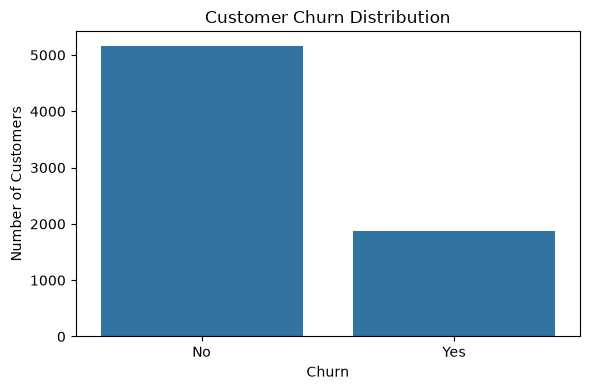

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../Images/churn_distribution.png", dpi=300)
plt.show()

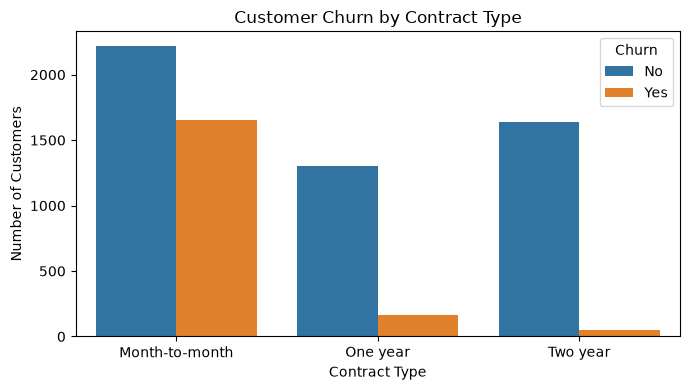

In [ ]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../Images/churn_by_contract.png", dpi=300)
plt.show()

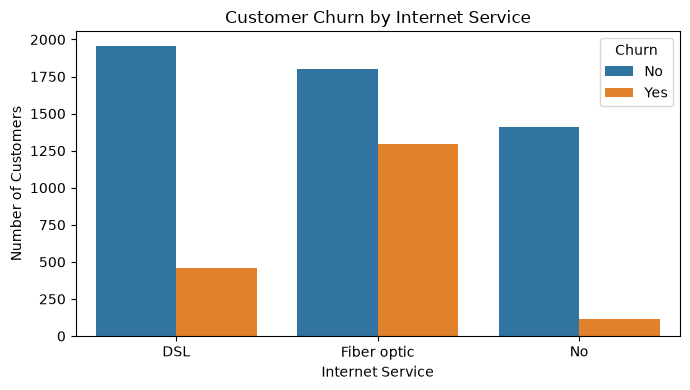

In [ ]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../Images/churn_by_internet_service.png", dpi=300)
plt.show()

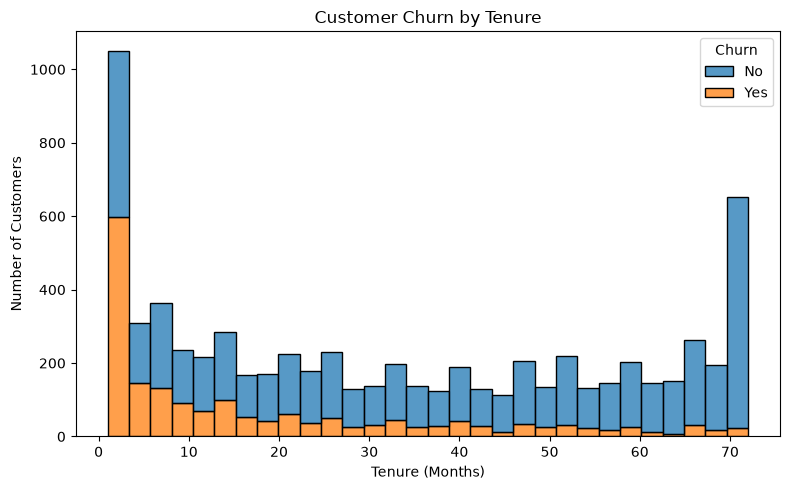

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="stack"
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../Images/churn_by_tenure.png", dpi=300)
plt.show()

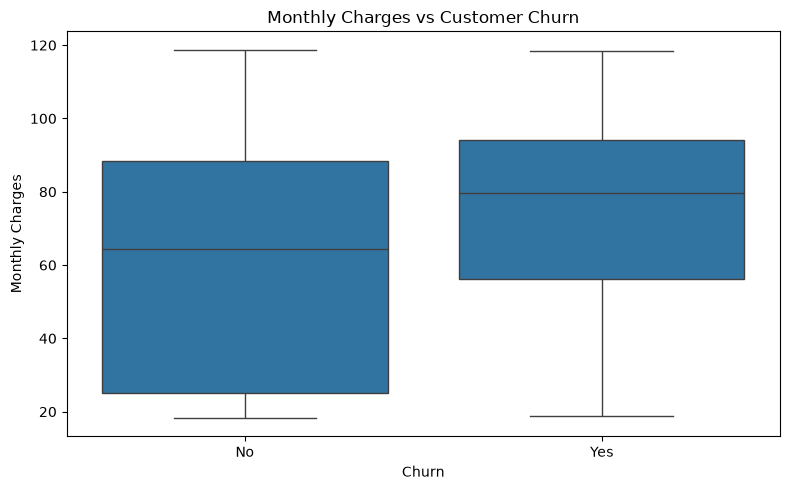

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.savefig("../Images/monthly_charges_vs_churn.png", dpi=300)
plt.show()

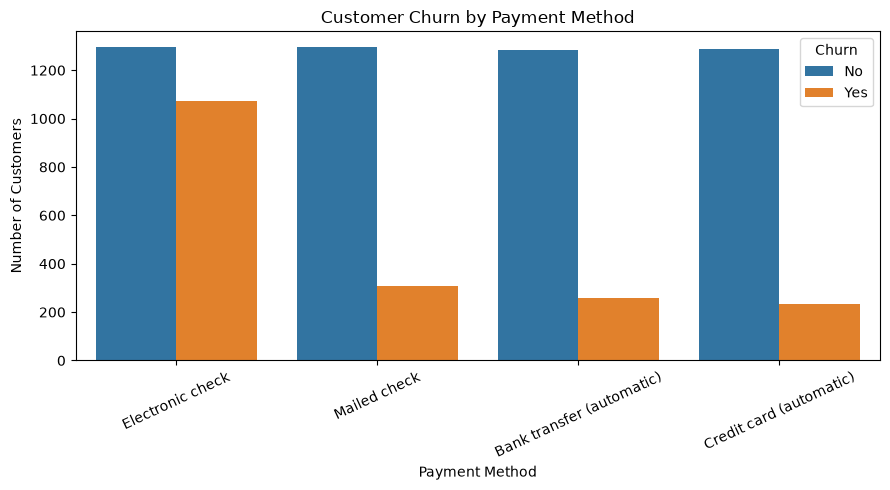

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=25)
plt.tight_layout()

plt.savefig("../Images/churn_by_payment_method.png", dpi=300)
plt.show()

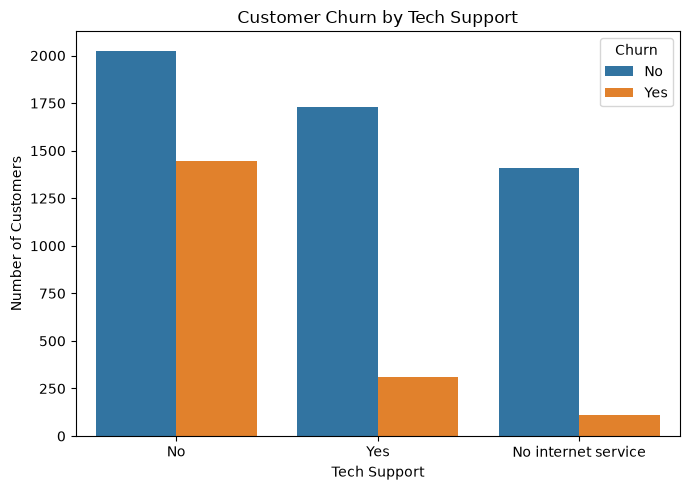

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="TechSupport", hue="Churn")

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../Images/churn_by_tech_support.png", dpi=300)
plt.show()

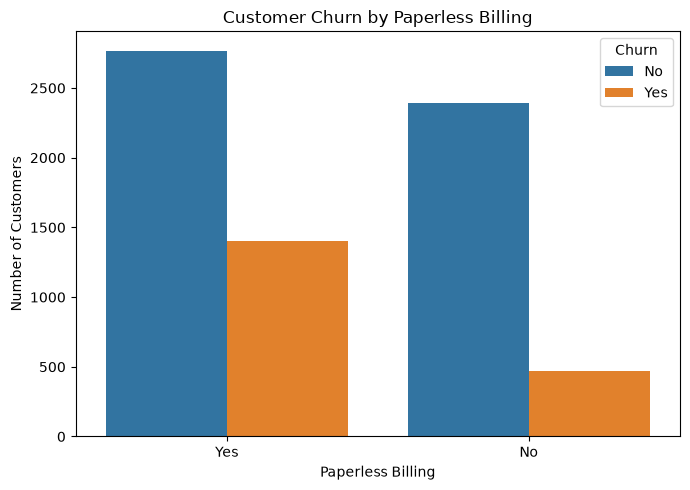

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="PaperlessBilling", hue="Churn")

plt.title("Customer Churn by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../Images/churn_by_paperless_billing.png", dpi=300)
plt.show()

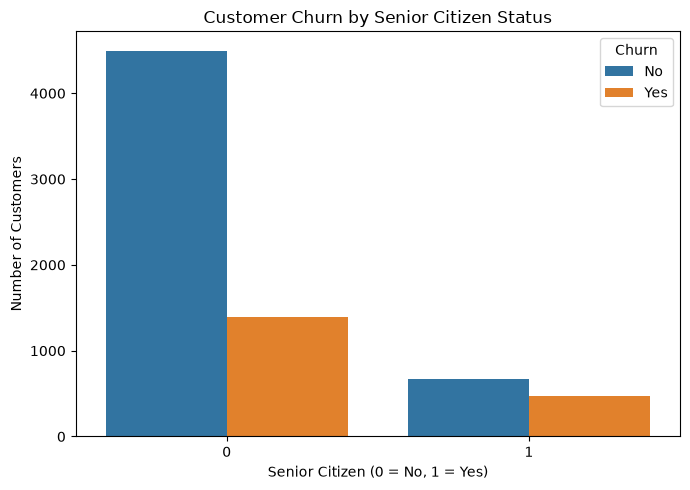

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../Images/churn_by_senior_citizen.png", dpi=300)
plt.show()

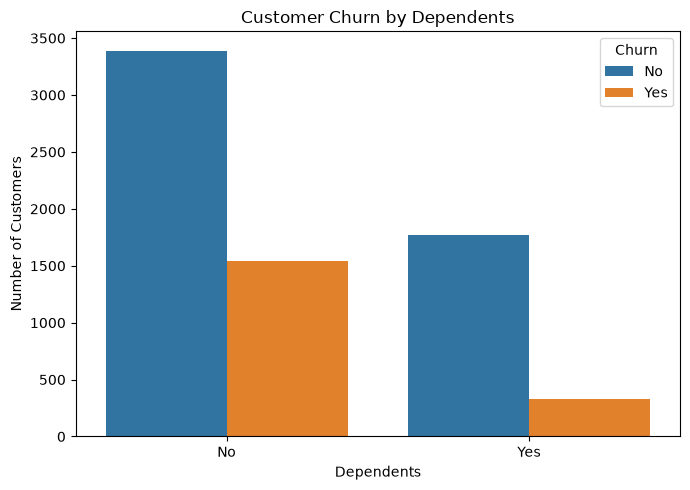

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Dependents", hue="Churn")

plt.title("Customer Churn by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../Images/churn_by_dependents.png", dpi=300)
plt.show()

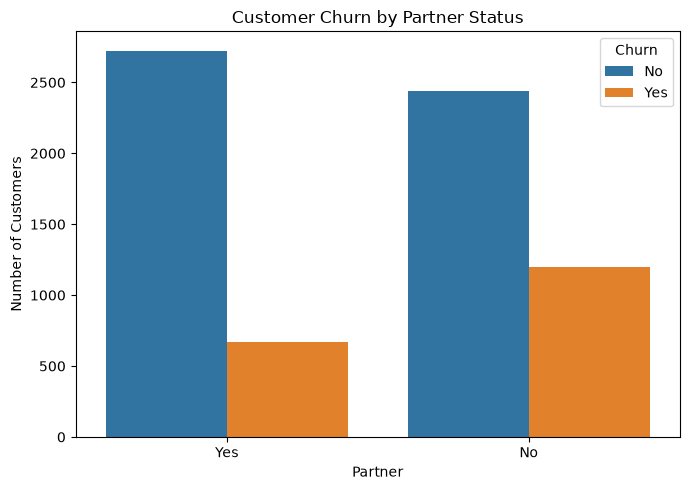

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Partner", hue="Churn")

plt.title("Customer Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../Images/churn_by_partner.png", dpi=300)
plt.show()

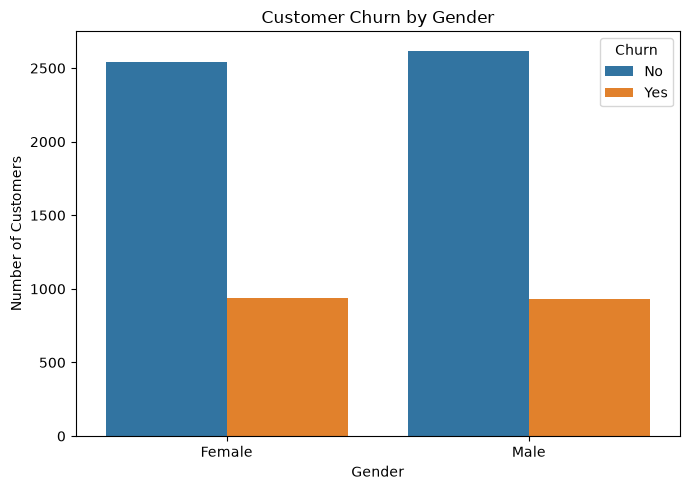

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../Images/churn_by_gender.png", dpi=300)
plt.show()

"Exploratory Data Analysis - Key Findings"
1. The dataset contains 7,032 cleaned customer records.
2. Approximately 26.58% of customers churned, while 73.42% remained with the company.
3. Customers with month-to-month contracts showed noticeably higher churn than customers with longer-term contracts.
4. iber optic customers showed a higher churn count compared with other internet service groups.
5. ustomers with lower tenure showed greater churn, indicating that newer customers may be more likely to leave.
6. Monthly charges showed differences between churned and non-churned customers.
7. Payment method, technical support, paperless billing, senior citizen status, dependents, and partner status showed useful churn patterns.
8. ender did not appear to show a major difference in churn behavior.
9. These findings will be used to guide feature preparation and machine learning model development.

In [ ]:
df.drop("customerID", axis=1, inplace=True)

df.shape

(7032, 20)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.dropna(subset=["TotalCharges"], inplace=True)

df.shape

(7032, 20)

In [ ]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
df_encoded.shape

(7032, 31)

In [ ]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 30)
y shape: (7032,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data:", X_train_scaled.shape)
print("Testing data:", X_test_scaled.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred_log = log_model.predict(X_test_scaled)

print("First 10 Predictions:")
print(y_pred_log[:10])

First 10 Predictions:
[0 1 0 0 0 0 0 0 1 0]


In [ ]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)
print("Accuracy Percentage:", round(log_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 0.8038379530916845
Accuracy Percentage: 80.38 %


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



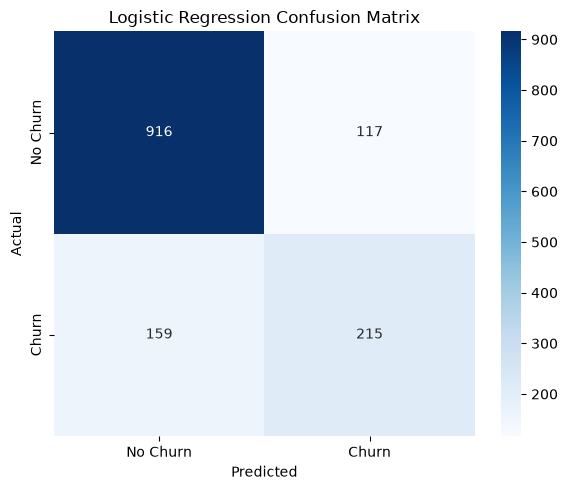

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("../Images/logistic_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("First 10 Random Forest Predictions:")
print(y_pred_rf[:10])

First 10 Random Forest Predictions:
[0 1 0 0 0 0 0 0 1 0]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 78.96 %

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



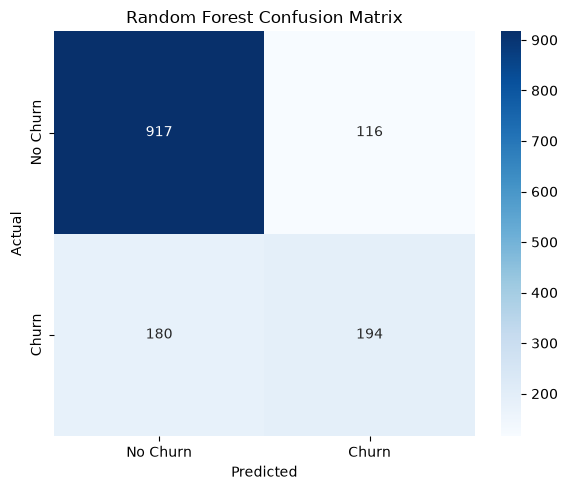

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("../Images/random_forest_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
print("MODEL COMPARISON")
print("----------------------------")
print("Logistic Regression:", round(log_accuracy * 100, 2), "%")
print("Random Forest:", round(rf_accuracy * 100, 2), "%")

MODEL COMPARISON
----------------------------
Logistic Regression: 80.38 %
Random Forest: 78.96 %


In [ ]:
import joblib

joblib.dump(log_model, "../Models/logistic_model.pkl")
joblib.dump(scaler, "../Models/scaler.pkl")

print("Final model and scaler saved successfully!")

Final model and scaler saved successfully!


In [ ]:
joblib.dump(X.columns.tolist(), "../Models/model_columns.pkl")

print("Model columns saved successfully!")
print("Total features:", len(X.columns))

Model columns saved successfully!
Total features: 30
